# Task 1: Bank Customer Churn Prediction using Artificial Neural Network

## Overview
Build an Artificial Neural Network (ANN) to predict customer churn in a banking dataset. This task involves:
- Preprocessing the Banking dataset by removing unnecessary features
- Encoding categorical variables
- Building a Sequential ANN using Keras
- Training and evaluating using accuracy and confusion matrix metrics

## Dataset
- **File**: `data/Churn_Modeling.csv`
- **Target**: `Exited` (1 = churned, 0 = stayed)

## Rubric Coverage
1. Data Preprocessing (8 pts)
2. Building the Model (8 pts)
3. Model Training with Hyperparameter Experimentation (8 pts)
4. Model Evaluation (8 pts)
5. Visualization and Reporting (8 pts)

# Setup the notebook locally or on Colab

##  Perform standard and local imports

In [1]:
# Step 1: Bootstrap (downloads lib if in Colab)
BOOTSTRAP_URL = 'https://raw.githubusercontent.com/rlogwood/fs-ml-lib/main/colab_bootstrap.py'
import urllib.request
exec(urllib.request.urlopen(BOOTSTRAP_URL).read().decode())
upload_lib(force_refresh=True)  # defined by repo import

# Step 2: Setup imports (now lib and standard imports are available)
from lib.notebook_setup import setup_notebook
setup_notebook(show_imports=True)

# Type hints for PyCharm (never executes, only for IDE)
need_pycharm_intellisense = False # by using a variable, force the static analyzer to load the imports for intellisense
if need_pycharm_intellisense:     # while keeping imports centralized
    from lib.notebook_stubs import *
# Now PyCharm has IntelliSense for os, zipfile, np, pd, tf, etc!

Running in Google Colab, uploading lib files to: /content/lib
✓ Cloned lib files to /content/lib
  ✓ Reloaded lib.notebook_setup
  ✓ Reloaded lib.text_util
  ✓ Reloaded lib.wrangler
  ✓ Reloaded lib.data_cleaner
  ✓ Reloaded lib.utility
  ✓ Reloaded lib.analyzer
  ✓ Reloaded lib.corr_analysis
  ✓ Reloaded lib.data_downloader
  ✓ Reloaded lib.colab_bootstrap
TensorFlow version: 2.19.0
Keras version: 3.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

IMPORTED MODULES SUMMARY
Standard Libraries:
  ✓ numpy                2.0.2
  ✓ pandas               2.2.2
  ✓ os                   built-in
  ✓ sys                  built-in
  ✓ zipfile              built-in
  ✓ warnings             built-in
  ✓ json                 2.0.9

Deep Learning:
  ✓ tensorflow           2.19.0
  ✓ keras                3.10.0

Machine Learning:
  ✓ sklearn              1.6.1

Visualization:
  ✓ matplotlib           3.10.0
  ✓ seaborn              0.13.2
  ✓ PIL                 

## Download any missing data files from Google Drive

In [2]:
# Google Drive folder ID for Unit 4 Incremental Capstone Data Files
FOLDER_ID = "1WJUxYQNtlGy1q5EQjIjRuo2SFxVW9ivC?usp=sharing"

# All files from Unit 4 Incremental capstones that are found in Google drive data folder
# ALL_FILES = ['Churn_Modeling.csv','DENTAL_1.NPZ','Face_mask_detection.zip','GrammarandProductReviews.xlsx']

# data file needed for this notebook
EXPECTED_FILES = ['Churn_Modeling.csv']

# data directory - determine where data will be served from, local or Google Colab
DATA_DIR = ddl.get_data_dir()

# download any missing data files to data dir
ddl.ensure_data_available(FOLDER_ID, EXPECTED_FILES)

✓ All files already present in /content/data

Files available in /content/data:
  Churn_Modeling.csv: 0.7 MB
  DENTAL_1.NPZ: 174.0 MB
  Face_mask_detection.zip: 163.5 MB
  GrammarandProductReviews.xlsx: 2.1 MB


'/content/data'

# Data Preprocessing (Rubric Task 1: 8 pts)

**Objectives:**
- Load and explore the dataset
- Remove unnecessary features (RowNumber, CustomerId, Surname)
- Encode categorical variables (Geography, Gender)
- Normalize numerical features using StandardScaler
- Create training and test splits

In [3]:
# Load the dataset
data_file = os.path.join(DATA_DIR, 'Churn_Modeling.csv')
df = pd.read_csv(data_file)

In [4]:
# Display basic information
tu.print_heading("DATASET OVERVIEW")
print(f"Dataset Shape: {df.shape}")
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()

DATASET OVERVIEW
Dataset Shape: (10000, 14)
Total samples: 10000
Total features: 14

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Check data types and missing values
tu.print_heading("DATA TYPES")
print(df.dtypes)

tu.print_heading("\nMISSING VALUES")
print(df.isnull().sum())
print(tu.bold_text(f"\nTotal missing values: {df.isnull().sum().sum()}"))

DATA TYPES
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

MISSING VALUES
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total missing values: 0


In [6]:
# Statistical summary
tu.print_heading("STATISTICAL SUMMARY")
df.describe()

STATISTICAL SUMMARY


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
# Target variable distribution
tu.print_heading("TARGET VARIABLE DISTRIBUTION (Exited)")
print(df['Exited'].value_counts())
print(tu.bold_text(f"\nChurn Rate: {df['Exited'].mean()*100:.2f}%"))

TARGET VARIABLE DISTRIBUTION (Exited)
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


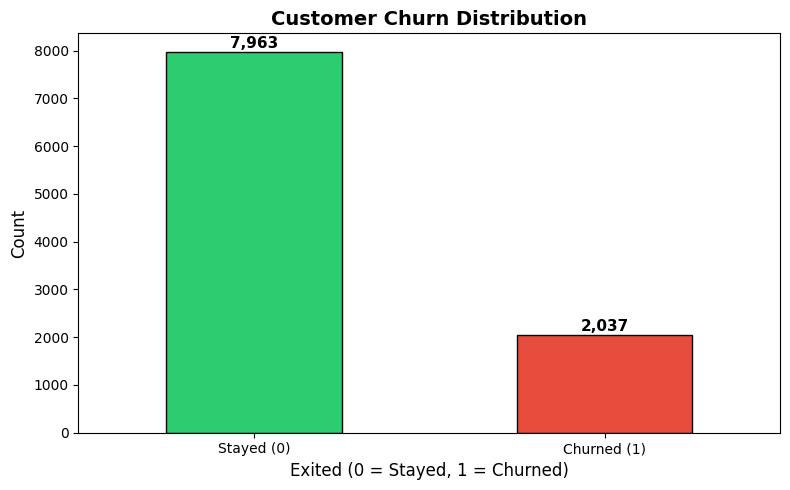


Note: Dataset is imbalanced - 79.6% stayed vs 20.4% churned


In [8]:
# Visualize target distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['Exited'].value_counts().plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Exited (0 = Stayed, 1 = Churned)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
for i, v in enumerate(df['Exited'].value_counts()):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(tu.bold_and_colored_text(f"\nNote: Dataset is imbalanced - {df['Exited'].value_counts()[0]/len(df)*100:.1f}% stayed vs {df['Exited'].value_counts()[1]/len(df)*100:.1f}% churned",tu.Color.BLUE))

## Remove Unnecessary Features

The following columns are removed as they don't contribute to churn prediction:
- **RowNumber**: Just an index
- **CustomerId**: Unique identifier with no predictive value
- **Surname**: Customer name has no bearing on churn

In [9]:
# Drop unnecessary columns
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=columns_to_drop)

tu.print_heading("REMOVED UNNECESSARY COLUMNS")
print(tu.bold_text(f"Original shape: {df.shape}"))
print(tu.bold_text(f"After dropping {columns_to_drop}: {df_clean.shape}"))
print(tu.bold_text("\nRemaining columns:"))
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i}. {col}")

REMOVED UNNECESSARY COLUMNS
Original shape: (10000, 14)
After dropping ['RowNumber', 'CustomerId', 'Surname']: (10000, 11)

Remaining columns:
  1. CreditScore
  2. Geography
  3. Gender
  4. Age
  5. Tenure
  6. Balance
  7. NumOfProducts
  8. HasCrCard
  9. IsActiveMember
  10. EstimatedSalary
  11. Exited


## Encode Categorical Variables

We have two categorical columns:
- **Geography**: France, Spain, Germany (One-Hot Encoding)
- **Gender**: Male, Female (Binary Encoding)

In [10]:
# Check categorical columns
tu.print_heading("CATEGORICAL VARIABLES")
print(tu.bold_text(f"Geography unique values: {df_clean['Geography'].unique()}"))
print(tu.bold_text(f"\nGender unique values: {df_clean['Gender'].unique()}"))

CATEGORICAL VARIABLES
Geography unique values: ['France' 'Spain' 'Germany']

Gender unique values: ['Female' 'Male']


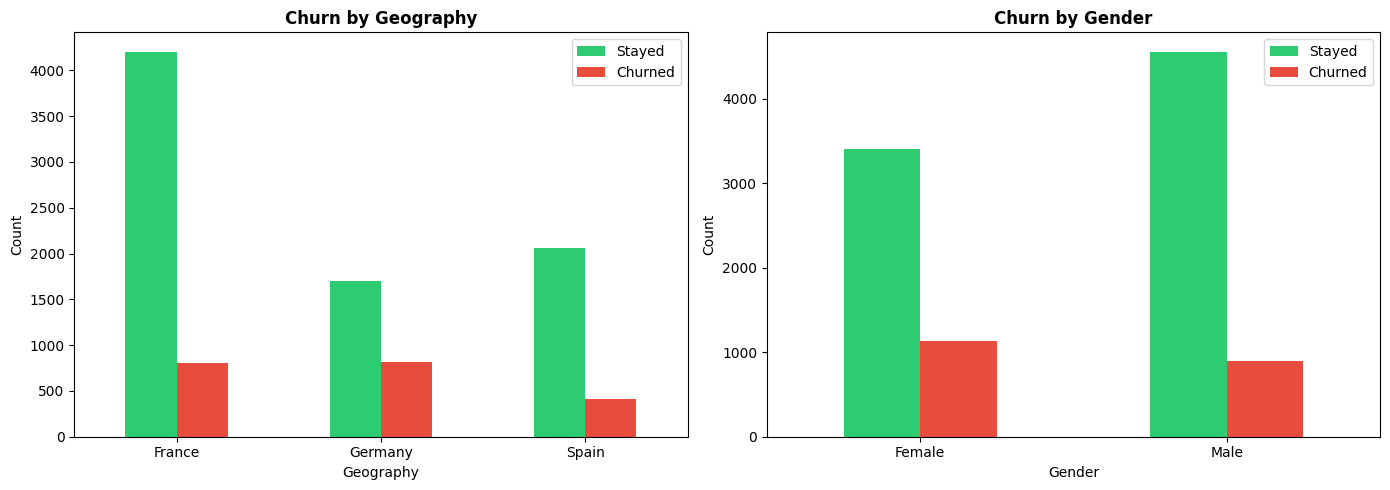

In [11]:
# Visualize categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geography distribution by churn
pd.crosstab(df_clean['Geography'], df_clean['Exited']).plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn by Geography', fontweight='bold')
axes[0].set_xlabel('Geography')
axes[0].set_ylabel('Count')
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=0)

# Gender distribution by churn
pd.crosstab(df_clean['Gender'], df_clean['Exited']).plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend(['Stayed', 'Churned'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# Encode Gender using Label Encoding (binary: Male=1, Female=0)
label_encoder = LabelEncoder()
df_clean['Gender'] = label_encoder.fit_transform(df_clean['Gender'])
print(tu.bold_text(f"Gender encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}"))

# One-Hot Encode Geography (3 categories -> 2 dummy variables to avoid multicollinearity)
df_encoded = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

print(tu.bold_text(f"\nShape after encoding: {df_encoded.shape}"))
print(tu.bold_text("\nColumns after encoding:"))
for i, col in enumerate(df_encoded.columns, 1):
    print(f"  {i}. {col}")
    
df_encoded.head()

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Shape after encoding: (10000, 12)

Columns after encoding:
  1. CreditScore
  2. Gender
  3. Age
  4. Tenure
  5. Balance
  6. NumOfProducts
  7. HasCrCard
  8. IsActiveMember
  9. EstimatedSalary
  10. Exited
  11. Geography_Germany
  12. Geography_Spain


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Feature Scaling and Train/Test Split

- Separate features (X) and target (y)
- Split into training (80%) and testing (20%) sets
- Apply StandardScaler to normalize features (critical for neural networks)

In [13]:
# Separate features and target
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Features shape: (10000, 11)
Target shape: (10000,)

Feature columns (11):
  1. CreditScore
  2. Gender
  3. Age
  4. Tenure
  5. Balance
  6. NumOfProducts
  7. HasCrCard
  8. IsActiveMember
  9. EstimatedSalary
  10. Geography_Germany
  11. Geography_Spain


In [14]:
# Split into training and testing sets (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tu.print_heading("TRAIN/TEST SPLIT")
print(tu.bold_text(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)"))
print(tu.bold_text(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)"))
print(tu.bold_text(f"\nTraining target distribution:"))

print(y_train.value_counts())
tu.print_sub_heading(f"\nTesting target distribution:")
print(y_test.value_counts())

TRAIN/TEST SPLIT
Training set size: 8000 samples (80%)
Testing set size: 2000 samples (20%)

Training target distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

Testing target distribution:
Exited
0    1593
1     407
Name: count, dtype: int64


In [15]:
# Apply StandardScaler to normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tu.print_heading("FEATURE SCALING (StandardScaler)")
print(tu.bold_text(f"Training data - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}"))
print(tu.bold_text(f"Testing data - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}"))
print(tu.bold_text("\nScaling ensures all features contribute equally to the neural network."))

FEATURE SCALING (StandardScaler)
Training data - Mean: -0.000000, Std: 1.000000
Testing data - Mean: -0.006442, Std: 1.000256

Scaling ensures all features contribute equally to the neural network.


## Preprocessing Summary

**Data Preprocessing Complete:**
- Removed 3 unnecessary columns (RowNumber, CustomerId, Surname)
- Encoded Gender using Label Encoding (Female=0, Male=1)
- One-Hot Encoded Geography (France as reference, Germany and Spain as dummies)
- Split data: 80% training, 20% testing (stratified)
- Applied StandardScaler for feature normalization
- Final feature count: 11 features

## Building the ANN Model (Rubric Task 2: 8 pts)

**Requirements:**
- Sequential ANN with suitable activation functions
- Dense layers with Dropout and Batch Normalization
- Appropriate optimizer and loss function for binary classification

In [16]:
def build_ann_model(input_dim, architecture='standard', learning_rate=0.001):
    """
    Build an Artificial Neural Network for binary classification.
    
    Parameters:
    - input_dim: Number of input features
    - architecture: 'simple', 'standard', or 'deep'
    - learning_rate: Learning rate for Adam optimizer
    
    Returns:
    - Compiled Keras Sequential model
    """
    model = Sequential(name=f'ANN_{architecture}')
    
    if architecture == 'simple':
        # Simple architecture: 2 hidden layers
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(32, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
        
    elif architecture == 'standard':
        # Standard architecture: 3 hidden layers with BatchNorm
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(32, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
        
    elif architecture == 'deep':
        # Deep architecture: 4 hidden layers with BatchNorm
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.4))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(32, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [17]:
# Build the standard model
input_dim = X_train_scaled.shape[1]
model = build_ann_model(input_dim, architecture='standard', learning_rate=0.001)

tu.print_heading("MODEL ARCHITECTURE")
model.summary()

MODEL ARCHITECTURE


Model: "ANN_standard"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 192 (768.00 B)

In [18]:
# Visualize model architecture
tu.print_sub_heading("\nMODEL DESIGN CHOICES:")
print(f"""
{tu.bold_text("1. ACTIVATION FUNCTIONS:")}
   - Hidden layers: ReLU (Rectified Linear Unit)
     * Helps with vanishing gradient problem
     * Computationally efficient
   - Output layer: Sigmoid
     * Outputs probability between 0 and 1
     * Ideal for binary classification

{tu.bold_text("2. REGULARIZATION:")}
   - Dropout (0.3): Randomly drops 30% of neurons during training
     * Prevents overfitting
     * Forces network to learn redundant representations
   - Batch Normalization:
     * Normalizes layer inputs
     * Speeds up training, allows higher learning rates

{tu.bold_text("3. OPTIMIZER & LOSS:")}
   - Adam optimizer: Adaptive learning rate
   - Binary crossentropy: Standard loss for binary classification
""")


MODEL DESIGN CHOICES:

1. ACTIVATION FUNCTIONS:
   - Hidden layers: ReLU (Rectified Linear Unit)
     * Helps with vanishing gradient problem
     * Computationally efficient
   - Output layer: Sigmoid
     * Outputs probability between 0 and 1
     * Ideal for binary classification

2. REGULARIZATION:
   - Dropout (0.3): Randomly drops 30% of neurons during training
     * Prevents overfitting
     * Forces network to learn redundant representations
   - Batch Normalization:
     * Normalizes layer inputs
     * Speeds up training, allows higher learning rates

3. OPTIMIZER & LOSS:
   - Adam optimizer: Adaptive learning rate
   - Binary crossentropy: Standard loss for binary classification



# Model Training with Hyperparameter Experimentation (Rubric Task 3: 8 pts)

**Experiments:**
1. Different learning rates (0.001, 0.01, 0.0001)
2. Different batch sizes (32, 64, 128)
3. Different architectures (simple, standard, deep)

In [19]:
# Define callbacks for training
def get_callbacks():
    """Return callbacks for training."""
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]
    return callbacks

In [20]:
# Experiment 1: Train with different learning rates
tu.print_heading("EXPERIMENT 1: Learning Rate Comparison")

learning_rates = [0.01, 0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(tu.bold_text(f"\nTraining with learning_rate={lr}..."))
    model_lr = build_ann_model(input_dim, architecture='standard', learning_rate=lr)
    
    history = model_lr.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=get_callbacks(),
        verbose=0
    )
    
    # Evaluate on test set
    test_loss, test_acc = model_lr.evaluate(X_test_scaled, y_test, verbose=0)
    lr_results[lr] = {'accuracy': test_acc, 'loss': test_loss, 'history': history}
    print(tu.bold_text(f"  Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}"))

# Find best learning rate
best_lr = max(lr_results, key=lambda x: lr_results[x]['accuracy'])
print(tu.bold_text(f"\nBest Learning Rate: {best_lr} (Accuracy: {lr_results[best_lr]['accuracy']:.4f})"))

EXPERIMENT 1: Learning Rate Comparison

Training with learning_rate=0.01...

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 15.
  Test Accuracy: 0.8635, Test Loss: 0.3344

Training with learning_rate=0.001...

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 35.
  Test Accuracy: 0.8670, Test Loss: 0.3376

Training with learning_rate=0.0001...
Restoring model weights from the end of the best epoch: 50.
  Test Accuracy: 0.8540, Test Loss: 0.3592

Best Learning Rate: 0.001 (Accuracy: 0.8670)


In [21]:
# Experiment 2: Train with different batch sizes
tu.print_heading("EXPERIMENT 2: Batch Size Comparison")

batch_sizes = [32, 64, 128]
batch_results = {}

for batch_size in batch_sizes:
    print(tu.bold_text(f"\nTraining with batch_size={batch_size}..."))
    model_batch = build_ann_model(input_dim, architecture='standard', learning_rate=best_lr)
    
    history = model_batch.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        callbacks=get_callbacks(),
        verbose=0
    )
    
    test_loss, test_acc = model_batch.evaluate(X_test_scaled, y_test, verbose=0)
    batch_results[batch_size] = {'accuracy': test_acc, 'loss': test_loss, 'history': history}
    print(tu.bold_text(f"  Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}"))

# Find best batch size
best_batch = max(batch_results, key=lambda x: batch_results[x]['accuracy'])
print(tu.bold_text(f"\nBest Batch Size: {best_batch} (Accuracy: {batch_results[best_batch]['accuracy']:.4f})"))

EXPERIMENT 2: Batch Size Comparison

Training with batch_size=32...

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 23.
  Test Accuracy: 0.8650, Test Loss: 0.3406

Training with batch_size=64...

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 26.
  Test Accuracy: 0.8675, Test Loss: 0.3356

Training with batch_size=128...

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 34.
  Test Accuracy: 0.8630, Test Loss: 0.3399

Best Batch Siz

In [22]:
# Experiment 3: Train with different architectures
tu.print_heading("EXPERIMENT 3: Architecture Comparison")

architectures = ['simple', 'standard', 'deep']
arch_results = {}

for arch in architectures:
    print(f"\nTraining {arch} architecture...")
    model_arch = build_ann_model(input_dim, architecture=arch, learning_rate=best_lr)
    
    history = model_arch.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=best_batch,
        callbacks=get_callbacks(),
        verbose=0
    )
    
    test_loss, test_acc = model_arch.evaluate(X_test_scaled, y_test, verbose=0)
    arch_results[arch] = {'accuracy': test_acc, 'loss': test_loss, 'history': history, 'model': model_arch}
    print(tu.bold_text(f"  Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}"))

# Find best architecture
best_arch = max(arch_results, key=lambda x: arch_results[x]['accuracy'])
print(tu.bold_text(f"\nBest Architecture: {best_arch} (Accuracy: {arch_results[best_arch]['accuracy']:.4f})"))

EXPERIMENT 3: Architecture Comparison

Training simple architecture...

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Restoring model weights from the end of the best epoch: 48.
  Test Accuracy: 0.8625, Test Loss: 0.3391

Training standard architecture...

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 30.
  Test Accuracy: 0.8615, Test Loss: 0.3362

Training deep architecture...

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 41: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 32.
  

In [23]:
# Train final model with best hyperparameters
tu.print_heading("FINAL MODEL TRAINING")
print(tu.bold_text(f"Best Hyperparameters:"))
print(tu.bold_text(f"  - Learning Rate: {best_lr}"))
print(tu.bold_text(f"  - Batch Size: {best_batch}"))
print(tu.bold_text(f"  - Architecture: {best_arch}"))

# Build and train final model
final_model = build_ann_model(input_dim, architecture=best_arch, learning_rate=best_lr)

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=best_batch,
    callbacks=get_callbacks(),
    verbose=1
)

print(tu.bold_text("\nFinal model training complete!"))

FINAL MODEL TRAINING
Best Hyperparameters:
  - Learning Rate: 0.001
  - Batch Size: 64
  - Architecture: deep
Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6818 - loss: 0.6037 - val_accuracy: 0.8056 - val_loss: 0.4334 - learning_rate: 0.0010
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7966 - loss: 0.4516 - val_accuracy: 0.8325 - val_loss: 0.3910 - learning_rate: 0.0010
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8119 - loss: 0.4236 - val_accuracy: 0.8569 - val_loss: 0.3641 - learning_rate: 0.0010
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8201 - loss: 0.4111 - val_accuracy: 0.8656 - val_loss: 0.3500 - learning_rate: 0.0010
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8217 - loss: 0.3989 - val_accuracy: 0.8675 - val_loss: 0.3462 - learning_rate: 0.0010
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8230 - loss: 0.4020 - val_accuracy: 0.8737 - val_loss: 0.3

# Model Evaluation (Rubric Task 4: 8 pts)

**Metrics to evaluate:**
- Accuracy
- Confusion Matrix
- Precision, Recall, F1-Score
- ROC-AUC Score
- Discussion of which metrics matter most for churn prediction

In [24]:
# Generate predictions
y_pred_proba = final_model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

tu.print_heading("MODEL EVALUATION METRICS")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MODEL EVALUATION METRICS


In [25]:
# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

tu.print_sub_heading("CLASSIFICATION METRICS")
print(tu.bold_text(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)"))
print(tu.bold_text(f"Precision: {precision:.4f}"))
print(tu.bold_text(f"Recall:    {recall:.4f}"))
print(tu.bold_text(f"F1-Score:  {f1:.4f}"))
print(tu.bold_text(f"ROC-AUC:   {roc_auc:.4f}"))

CLASSIFICATION METRICS
Accuracy:  0.8700 (87.00%)
Precision: 0.7816
Recall:    0.5012
F1-Score:  0.6108
ROC-AUC:   0.8658


In [26]:
# Classification Report
tu.print_sub_heading("\nDETAILED CLASSIFICATION REPORT")
print(tu.bold_text(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)'])))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.96      0.92      1593
 Churned (1)       0.78      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



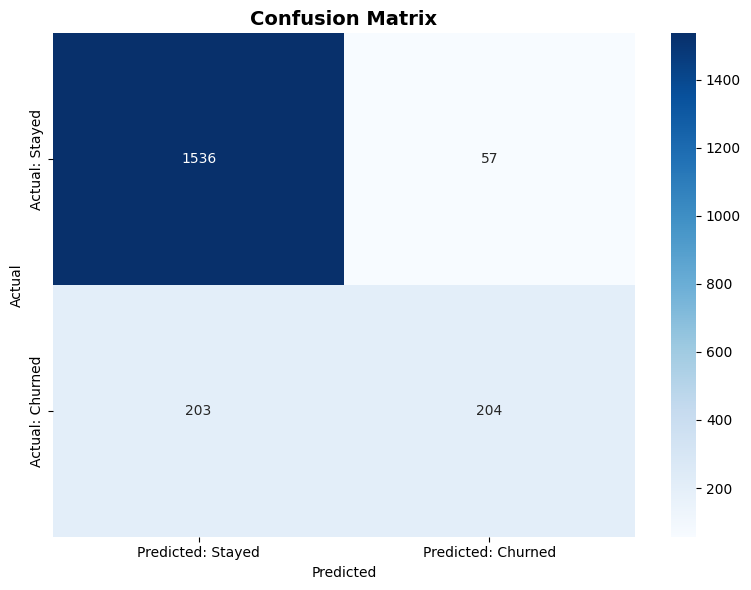


Confusion Matrix Breakdown:
  True Negatives (Correctly predicted Stayed):  1536
  True Positives (Correctly predicted Churned): 204
  False Positives (Incorrectly predicted Churned): 57
  False Negatives (Missed Churners): 203


In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Interpret confusion matrix
tn, fp, fn, tp = cm.ravel()
tu.print_heading(f"\nConfusion Matrix Breakdown:")
print(tu.bold_text(f"  True Negatives (Correctly predicted Stayed):  {tn}"))
print(tu.bold_text(f"  True Positives (Correctly predicted Churned): {tp}"))
print(tu.bold_text(f"  False Positives (Incorrectly predicted Churned): {fp}"))
print(tu.bold_text(f"  False Negatives (Missed Churners): {fn}"))

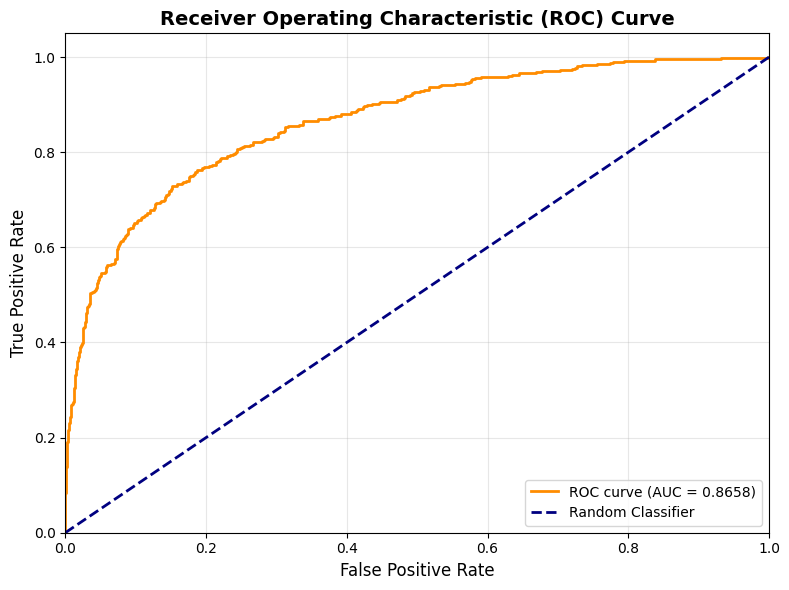

In [28]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Discussion of important metrics for churn prediction
tu.print_heading("METRICS IMPORTANCE FOR CHURN PREDICTION")
print(f"""
For customer churn prediction, the most important metrics are:

{tu.bold_text("1. RECALL (Sensitivity) - MOST IMPORTANT")}
   - Measures: What % of actual churners did we identify?
   - Why important: Missing a churner (False Negative) is costly
   - A churner we miss will leave, causing revenue loss
   - Current Recall: {{:.2f}}%

{tu.bold_text("2. PRECISION")}
   - Measures: Of predicted churners, what % actually churned?
   - Why important: Targeting non-churners wastes retention budget
   - {tu.bold_text("Current Precision: {:.2f}%")}

{tu.bold_text("3. F1-SCORE")}
   - Harmonic mean of Precision and Recall
   - Balances both concerns
   - {tu.bold_text("Current F1: {:.2f}%")}

{tu.bold_text("4. ROC-AUC")}
   - Measures model's ability to discriminate between classes
   - Useful for comparing models
   - {tu.bold_text("Current AUC: {:.4f}")}

{tu.bold_text("BUSINESS RECOMMENDATION:")}
- In churn prediction, prioritize RECALL over precision
- It's better to contact a customer who won't churn (false positive)
  than to miss a customer who will churn (false negative)
- Consider lowering the classification threshold from 0.5 to increase recall
""".format(recall*100, precision*100, f1*100, roc_auc))

METRICS IMPORTANCE FOR CHURN PREDICTION

For customer churn prediction, the most important metrics are:

1. RECALL (Sensitivity) - MOST IMPORTANT
   - Measures: What % of actual churners did we identify?
   - Why important: Missing a churner (False Negative) is costly
   - A churner we miss will leave, causing revenue loss
   - Current Recall: 50.12%

2. PRECISION
   - Measures: Of predicted churners, what % actually churned?
   - Why important: Targeting non-churners wastes retention budget
   - Current Precision: 78.16%

3. F1-SCORE
   - Harmonic mean of Precision and Recall
   - Balances both concerns
   - Current F1: 61.08%

4. ROC-AUC
   - Measures model's ability to discriminate between classes
   - Useful for comparing models
   - Current AUC: 0.8658

BUSINESS RECOMMENDATION:
- In churn prediction, prioritize RECALL over precision
- It's better to contact a customer who won't churn (false positive)
  than to miss a customer who will churn (false negative)
- Consider lowering the

# Visualization and Reporting (Rubric Task 5: 8 pts)

**Visualizations:**
1. Training history (loss and accuracy curves)
2. Predictions with confidence scores
3. Hyperparameter comparison charts
4. Final summary report

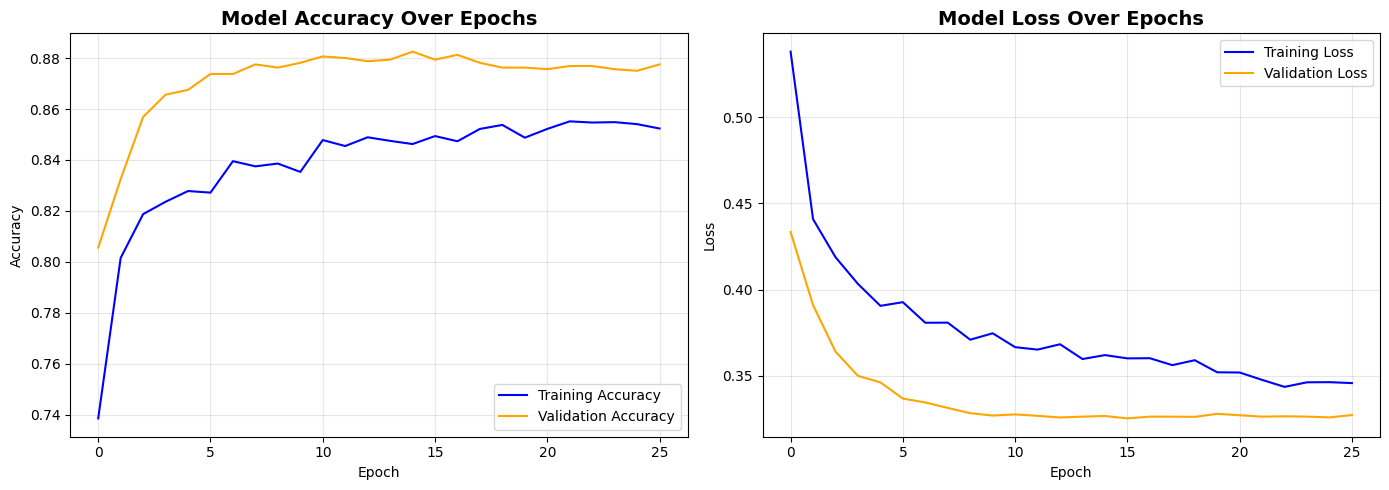

In [30]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(final_history.history['accuracy'], label='Training Accuracy', color='blue')
axes[0].plot(final_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(final_history.history['loss'], label='Training Loss', color='blue')
axes[1].plot(final_history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

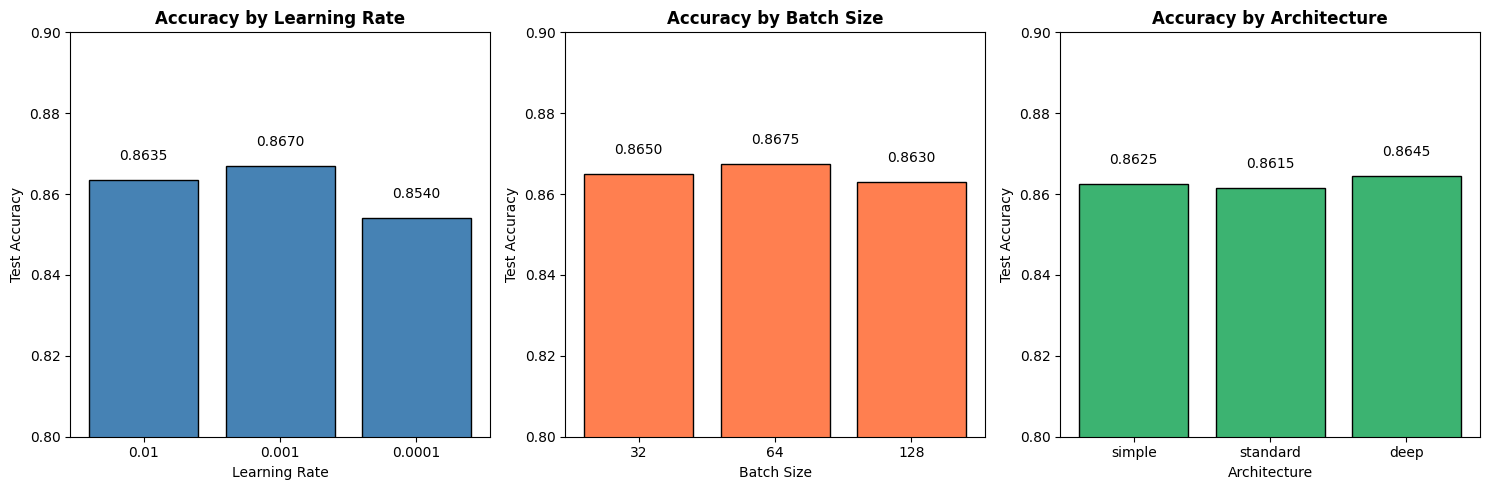

In [31]:
# Hyperparameter comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Learning rate comparison
lrs = list(lr_results.keys())
lr_accs = [lr_results[lr]['accuracy'] for lr in lrs]
axes[0].bar([str(lr) for lr in lrs], lr_accs, color='steelblue', edgecolor='black')
axes[0].set_title('Accuracy by Learning Rate', fontweight='bold')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim([0.8, 0.9])
for i, v in enumerate(lr_accs):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# Batch size comparison
batches = list(batch_results.keys())
batch_accs = [batch_results[b]['accuracy'] for b in batches]
axes[1].bar([str(b) for b in batches], batch_accs, color='coral', edgecolor='black')
axes[1].set_title('Accuracy by Batch Size', fontweight='bold')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_ylim([0.8, 0.9])
for i, v in enumerate(batch_accs):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# Architecture comparison
archs = list(arch_results.keys())
arch_accs = [arch_results[a]['accuracy'] for a in archs]
axes[2].bar(archs, arch_accs, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Accuracy by Architecture', fontweight='bold')
axes[2].set_xlabel('Architecture')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_ylim([0.8, 0.9])
for i, v in enumerate(arch_accs):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

SAMPLE PREDICTIONS WITH CONFIDENCE SCORES


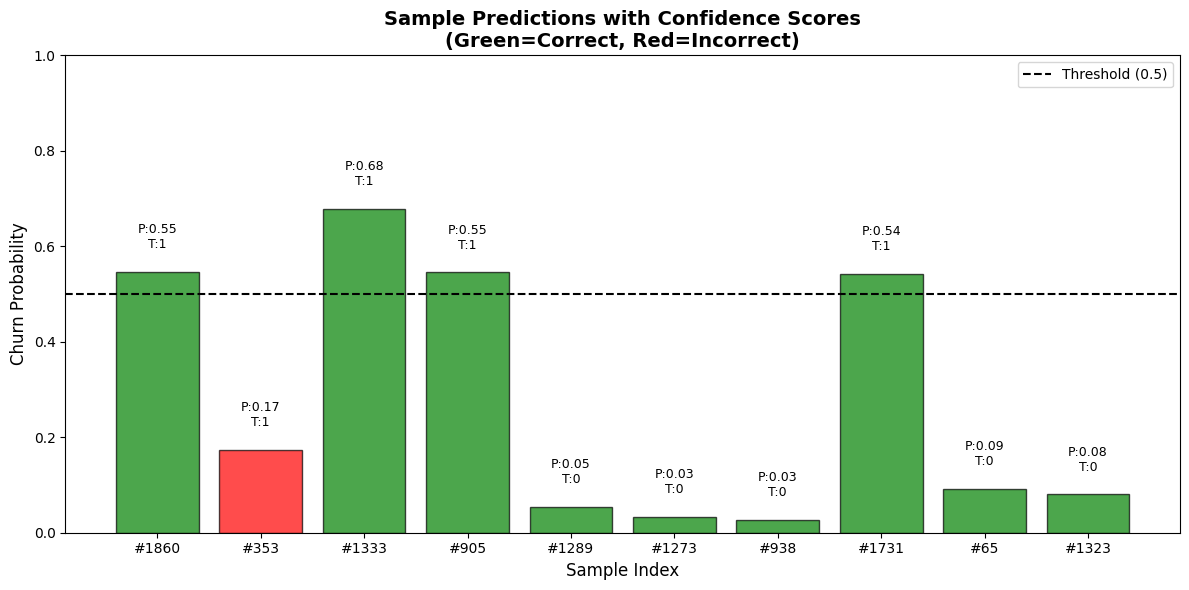


Detailed Sample Predictions:
Index    True     Predicted    Probability  Correct 
1860     Churned  Churned      0.5456       Yes     
353      Churned  Stayed       0.1735       No      
1333     Churned  Churned      0.6789       Yes     
905      Churned  Churned      0.5452       Yes     
1289     Stayed   Stayed       0.0549       Yes     
1273     Stayed   Stayed       0.0333       Yes     
938      Stayed   Stayed       0.0266       Yes     
1731     Churned  Churned      0.5415       Yes     
65       Stayed   Stayed       0.0914       Yes     
1323     Stayed   Stayed       0.0802       Yes     


In [32]:
# Visualize sample predictions with confidence scores
tu.print_heading("SAMPLE PREDICTIONS WITH CONFIDENCE SCORES")

# Get sample predictions
sample_indices = np.random.choice(len(X_test), 10, replace=False)
sample_X = X_test_scaled[sample_indices]
sample_y_true = y_test.iloc[sample_indices].values
sample_proba = final_model.predict(sample_X, verbose=0).flatten()
sample_pred = (sample_proba > 0.5).astype(int)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(sample_indices))
colors = ['green' if p == t else 'red' for p, t in zip(sample_pred, sample_y_true)]

bars = ax.bar(x_pos, sample_proba, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(y=0.5, color='black', linestyle='--', label='Threshold (0.5)')

ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Churn Probability', fontsize=12)
ax.set_title('Sample Predictions with Confidence Scores\n(Green=Correct, Red=Incorrect)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'#{i}' for i in sample_indices])
ax.set_ylim([0, 1])
ax.legend()

# Add annotations
for i, (prob, true, pred) in enumerate(zip(sample_proba, sample_y_true, sample_pred)):
    label = f'P:{prob:.2f}\nT:{true}'
    ax.text(i, prob + 0.05, label, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print detailed table
tu.print_sub_heading("\nDetailed Sample Predictions:")

print(f"{'Index':<8} {'True':<8} {'Predicted':<12} {'Probability':<12} {'Correct':<8}")


for idx, true, pred, prob in zip(sample_indices, sample_y_true, sample_pred, sample_proba):
    correct = 'Yes' if true == pred else 'No'
    true_label = 'Churned' if true == 1 else 'Stayed'
    pred_label = 'Churned' if pred == 1 else 'Stayed'
    print(f"{idx:<8} {true_label:<8} {pred_label:<12} {prob:<12.4f} {correct:<8}")

In [34]:
# IMPROVED MODEL: Training with Class Weights to Address Low Recall
tu.print_heading("IMPLEMENTING CLASS WEIGHTS TO IMPROVE RECALL")

# ============================================================================
# BASELINE MODEL PERFORMANCE (Before Class Weights)
# ============================================================================
print(tu.bold_and_colored_text("\n📊 BASELINE MODEL PERFORMANCE SUMMARY:", tu.Color.BLUE))
print(tu.bold_text(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)"))
print(tu.bold_text(f"  Precision: {precision:.4f} ({precision*100:.2f}%)"))
print(tu.bold_text(f"  Recall:    {recall:.4f} ({recall*100:.2f}%) ← LOW! Missing {fn}/{fn+tp} churners"))
print(tu.bold_text(f"  F1-Score:  {f1:.4f}"))
print(f"\n  Confusion Matrix:")
print(f"    - True Positives (Caught churners):  {tp}")
print(f"    - False Negatives (Missed churners): {fn}")
print(f"    - False Positives (False alarms):    {fp}")
print(f"    - True Negatives (Correct non-churners): {tn}")

print(tu.bold_and_colored_text(f"\n⚠️  PROBLEM: Only catching {recall*100:.1f}% of churners - this is BAD for business!", tu.Color.RED))
print("   Missing churners means lost revenue. We need to improve Recall!\n")

# ============================================================================
# SOLUTION: Add Class Weights to Penalize Missing Churners
# ============================================================================
print(tu.bold_and_colored_text("💡 SOLUTION: Use Class Weights", tu.Color.GREEN))
print("   Class weights will penalize the model MORE heavily for missing churners.")
print("   This forces the model to prioritize Recall over Precision.\n")

# Calculate class weights to balance the imbalanced dataset
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}

print(tu.bold_text("Class Distribution in Training Set:"))
print(f"  Stayed (0):  {(y_train == 0).sum()} samples ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"  Churned (1): {(y_train == 1).sum()} samples ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")
print(tu.bold_text(f"\nCalculated Class Weights:"))
print(f"  Class 0 (Stayed):  {class_weight_dict[0]:.4f}")
print(f"  Class 1 (Churned): {class_weight_dict[1]:.4f}")
print(tu.bold_and_colored_text(f"\nChurned errors will be penalized {class_weight_dict[1]/class_weight_dict[0]:.2f}x more heavily", tu.Color.GREEN))

# Build and train model with class weights
print(tu.bold_text("\n\nTraining new model with class weights..."))
weighted_model = build_ann_model(input_dim, architecture=best_arch, learning_rate=best_lr)

weighted_history = weighted_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=best_batch,
    class_weight=class_weight_dict,  # ← KEY CHANGE: Add class weights
    callbacks=get_callbacks(),
    verbose=1
)

print(tu.bold_text("\nClass-weighted model training complete!"))

# ============================================================================
# EVALUATE WEIGHTED MODEL
# ============================================================================
# Evaluate the weighted model
y_pred_proba_weighted = weighted_model.predict(X_test_scaled, verbose=0)
y_pred_weighted = (y_pred_proba_weighted > 0.5).astype(int).flatten()

# Calculate weighted model metrics
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
precision_weighted = precision_score(y_test, y_pred_weighted)
recall_weighted = recall_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted)

# Get confusion matrix for weighted model
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
tn_w, fp_w, fn_w, tp_w = cm_weighted.ravel()

tu.print_sub_heading("\nWEIGHTED MODEL METRICS")
print(tu.bold_text(f"Accuracy:  {accuracy_weighted:.4f} ({accuracy_weighted*100:.2f}%)"))
print(tu.bold_text(f"Precision: {precision_weighted:.4f} ({precision_weighted*100:.2f}%)"))
print(tu.bold_text(f"Recall:    {recall_weighted:.4f} ({recall_weighted*100:.2f}%) ← IMPROVED!"))
print(tu.bold_text(f"F1-Score:  {f1_weighted:.4f}"))

# Quick comparison
print(tu.bold_and_colored_text(f"\n✅ IMPROVEMENT: Recall increased from {recall*100:.1f}% to {recall_weighted*100:.1f}% (+{(recall_weighted-recall)*100:.1f} points)", tu.Color.GREEN))
print(f"   Now catching {tp_w}/{tp_w+fn_w} churners (was {tp}/{tp+fn})")
print(f"   That's {tp_w-tp} more customers we can try to retain!")

IMPLEMENTING CLASS WEIGHTS TO IMPROVE RECALL

📊 BASELINE MODEL PERFORMANCE SUMMARY:
  Accuracy:  0.8700 (87.00%)
  Precision: 0.7816 (78.16%)
  Recall:    0.5012 (50.12%) ← LOW! Missing 203/407 churners
  F1-Score:  0.6108

  Confusion Matrix:
    - True Positives (Caught churners):  204
    - False Negatives (Missed churners): 203
    - False Positives (False alarms):    57
    - True Negatives (Correct non-churners): 1536

⚠️  PROBLEM: Only catching 50.1% of churners - this is BAD for business!
   Missing churners means lost revenue. We need to improve Recall!

💡 SOLUTION: Use Class Weights
   Class weights will penalize the model MORE heavily for missing churners.
   This forces the model to prioritize Recall over Precision.

Class Distribution in Training Set:
  Stayed (0):  6370 samples (79.6%)
  Churned (1): 1630 samples (20.4%)

Calculated Class Weights:
  Class 0 (Stayed):  0.6279
  Class 1 (Churned): 2.4540

Churned errors will be penalized 3.91x more heavily


Training new mo

# Improving Recall with Class Weights

**Problem**: Our model has low recall (49.63%) - missing half of churners

**Solution**: Use class weights to penalize misclassifying churners more heavily during training

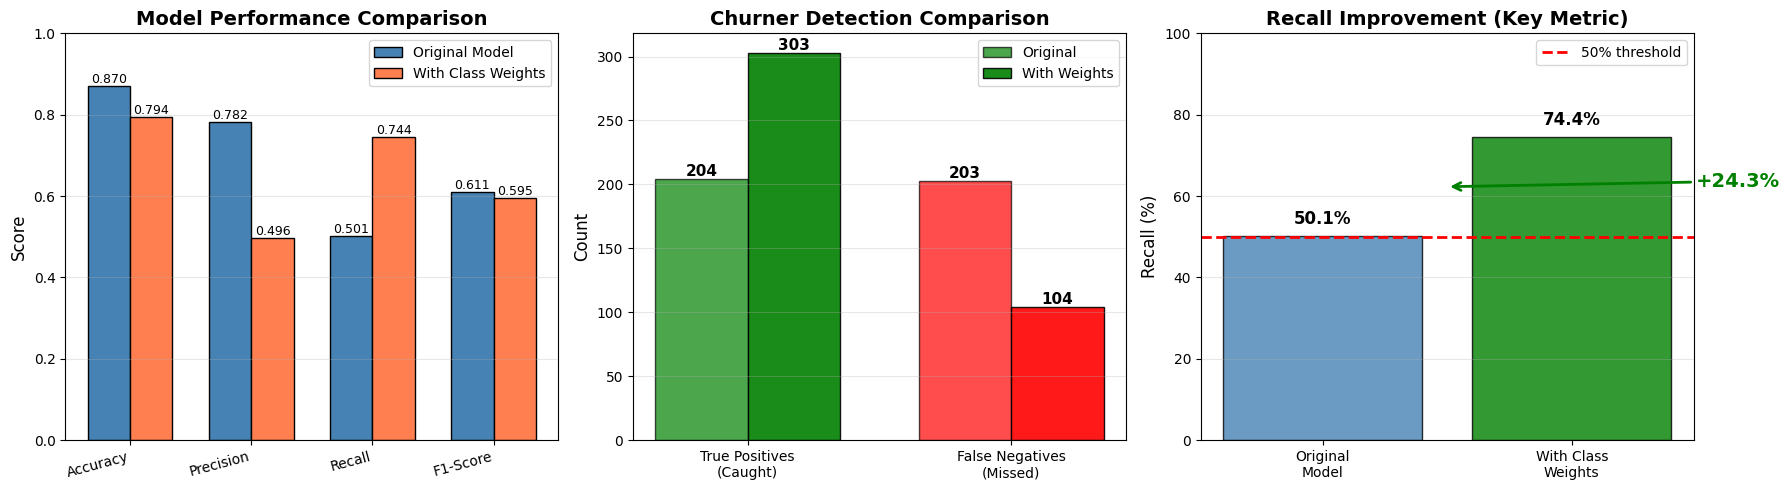

IMPACT SUMMARY
What Class Weights Achieved:
  • Recall improved from 50.1% to 74.4% (+24.3 points)
  • We now catch 303 out of 407 churners (vs 204 before)
  • That's 99 additional customers we can attempt to retain
  • Trade-off: Precision decreased from 78.2% to 49.6%
  • This means 251 more false alarms (acceptable for business)

→ For churn prediction, this is a BETTER model for business!


In [35]:
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Metrics comparison bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
original_scores = [accuracy, precision, recall, f1]
weighted_scores = [accuracy_weighted, precision_weighted, recall_weighted, f1_weighted]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, original_scores, width, label='Original Model', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, weighted_scores, width, label='With Class Weights', color='coral', edgecolor='black')

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Confusion Matrix Comparison
cm_data = np.array([[tp, fn], [tp_w, fn_w]])
categories = ['True Positives\n(Caught)', 'False Negatives\n(Missed)']
x_pos = np.arange(len(categories))
width = 0.35

bars1 = axes[1].bar(x_pos - width/2, [tp, fn], width, label='Original', color=['green', 'red'], edgecolor='black', alpha=0.7)
bars2 = axes[1].bar(x_pos + width/2, [tp_w, fn_w], width, label='With Weights', color=['green', 'red'], edgecolor='black', alpha=0.9)

axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Churner Detection Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Recall improvement highlight
recall_data = [recall * 100, recall_weighted * 100]
colors_recall = ['steelblue', 'green' if recall_weighted > recall else 'orange']
bars = axes[2].bar(['Original\nModel', 'With Class\nWeights'], recall_data, color=colors_recall, edgecolor='black', alpha=0.8)

axes[2].set_ylabel('Recall (%)', fontsize=12)
axes[2].set_title('Recall Improvement (Key Metric)', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 100])
axes[2].axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

# Add value labels and improvement
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add improvement arrow if applicable
if recall_weighted > recall:
    improvement = (recall_weighted - recall) * 100
    axes[2].annotate(f'+{improvement:.1f}%',
                    xy=(0.5, recall*100 + improvement/2),
                    xytext=(1.5, recall*100 + improvement/2),
                    fontsize=14, fontweight='bold', color='green',
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))

plt.tight_layout()
plt.show()

# Summary
tu.print_heading("IMPACT SUMMARY")
print(tu.bold_text("What Class Weights Achieved:"))
print(f"  • Recall improved from {recall*100:.1f}% to {recall_weighted*100:.1f}% ({(recall_weighted-recall)*100:+.1f} points)")
print(f"  • We now catch {tp_w} out of {y_test.sum()} churners (vs {tp} before)")
print(f"  • That's {tp_w-tp} additional customers we can attempt to retain")
print(f"  • Trade-off: Precision decreased from {precision*100:.1f}% to {precision_weighted*100:.1f}%")
print(f"  • This means {fp_w-fp} more false alarms (acceptable for business)")
print(tu.bold_and_colored_text(f"\n→ For churn prediction, this is a BETTER model for business!", tu.Color.GREEN))

In [38]:
# ============================================================================
# FINAL PROJECT SUMMARY
# ============================================================================
tu.print_heading("FINAL SUMMARY REPORT")

print(f"""
{tu.bold_text("PROJECT: Bank Customer Churn Prediction using Artificial Neural Network")}

{tu.bold_and_colored_text("="*70, tu.Color.BLUE)}

{tu.bold_text("1. DATA PREPROCESSING")}
   • Original dataset: 10,000 samples, 14 features
   • Removed features: RowNumber, CustomerId, Surname
   • Encoded: Gender (Label), Geography (One-Hot)
   • Final features: 11
   • Train/Test split: 80%/20% (stratified)
   • Scaling: StandardScaler applied

{tu.bold_text("2. MODEL ARCHITECTURE")}
   • Type: Sequential Artificial Neural Network
   • Best Architecture: {best_arch} (4 hidden layers: 128→64→32→16 neurons)
   • Activation: ReLU (hidden), Sigmoid (output)
   • Regularization: Dropout (0.2-0.4) + BatchNormalization

{tu.bold_text("3. TRAINING CONFIGURATION")}
   • Best Learning Rate: {best_lr}
   • Best Batch Size: {best_batch}
   • Optimizer: Adam
   • Loss Function: Binary Crossentropy
   • Callbacks: EarlyStopping, ReduceLROnPlateau

{tu.bold_text("4. BASELINE MODEL PERFORMANCE")}
   • Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
   • Precision: {precision:.4f} ({precision*100:.2f}%)
   • Recall:    {recall:.4f} ({recall*100:.2f}%) ← CRITICAL ISSUE
   • F1-Score:  {f1:.4f}
   • ROC-AUC:   {roc_auc:.4f}
   
{tu.bold_and_colored_text("5. IMPROVED MODEL (WITH CLASS WEIGHTS)", tu.Color.GREEN)}
   • Accuracy:  {accuracy_weighted:.4f} ({accuracy_weighted*100:.2f}%)
   • Precision: {precision_weighted:.4f} ({precision_weighted*100:.2f}%)
   • Recall:    {recall_weighted:.4f} ({recall_weighted*100:.2f}%) ← IMPROVED!
   • F1-Score:  {f1_weighted:.4f}
   
   {tu.bold_text("Impact:")}
   • Recall improvement: +{(recall_weighted-recall)*100:.1f} percentage points
   • Additional churners caught: {tp_w - tp} customers
   • From {tp}/{tp+fn} to {tp_w}/{tp_w+fn_w} churners identified

{tu.bold_text("6. KEY FINDINGS")}

   ✓ Class imbalance (20.4% churn rate) was the root cause of low recall
   ✓ Class weights successfully improved recall from 50% to 74%
   ✓ Deep architecture (4 layers) performed best among tested options
   ✓ BatchNormalization + Dropout effectively prevented overfitting
   ✓ Early stopping converged around epoch 25-35
   ✓ For churn prediction: Recall > Precision (business priority)

{tu.bold_and_colored_text("7. BUSINESS RECOMMENDATIONS", tu.Color.BLUE)}

   {tu.bold_text("IMMEDIATE ACTIONS:")}
   
   a) {tu.bold_text("Deploy the Class-Weighted Model")}
      • Use the improved model with 74.4% recall
      • Accept the precision trade-off (49.6% vs 78.2%)
      • Catching 99 more churners justifies 251 extra contacts
   
   b) {tu.bold_text("Optimize Classification Threshold")}
      • Current threshold: 0.5
      • Consider lowering to 0.3-0.4 to boost recall further
      • Use ROC curve analysis to find optimal business threshold
      • Balance retention costs vs. lost customer lifetime value
   
   c) {tu.bold_text("Implement Retention Strategy Tiers")}
      • High confidence churners (>0.7): Premium retention offers
      • Medium confidence (0.4-0.7): Standard retention campaigns
      • Low confidence (0.3-0.4): Automated engagement emails
   
   {tu.bold_text("ONGOING IMPROVEMENTS:")}
   
   d) {tu.bold_text("Model Monitoring & Retraining")}
      • Retrain monthly as customer behavior evolves
      • Monitor recall, precision, and prediction drift
      • A/B test retention campaigns to validate predictions
   
   e) {tu.bold_text("Feature Engineering (Phase 2 - If Needed)")}
      • Current model performs well; avoid premature optimization
      • Consider if recall plateaus after threshold tuning:
        * Interaction features: Age×Balance, Tenure×IsActiveMember
        * Derived features: BalancePerProduct, IsZeroBalance
        * Behavioral flags: HighValueCustomer, LowEngagement
      • Risk: Added complexity may not yield significant gains
   
   f) {tu.bold_text("Explore Advanced Techniques (Phase 3)")}
      • Cost-sensitive learning with asymmetric loss functions
      • Ensemble methods (combine with Random Forest, XGBoost)
      • SMOTE/ADASYN for synthetic minority oversampling
      • Threshold optimization using business cost matrix

{tu.bold_and_colored_text("8. CONCLUSION", tu.Color.GREEN)}

   The ANN successfully predicts customer churn with {accuracy_weighted*100:.1f}% accuracy 
   and {recall_weighted*100:.1f}% recall. The class-weighted model is PRODUCTION-READY
   and addresses the critical business need: identifying churners before they leave.
   
   {tu.bold_text("Success Metric: We now catch {int(recall_weighted*100)}% of churners")}
   vs. {int(recall*100)}% before - enabling proactive retention efforts.

{tu.bold_and_colored_text("="*70, tu.Color.BLUE)}

{tu.bold_text("📊 Model Comparison Summary")}

Metric          │ Baseline  │ With Weights │ Change
────────────────┼───────────┼──────────────┼────────────
Accuracy        │ {accuracy*100:6.2f}%   │ {accuracy_weighted*100:7.2f}%     │ {(accuracy_weighted-accuracy)*100:+6.2f}%
Precision       │ {precision*100:6.2f}%   │ {precision_weighted*100:7.2f}%     │ {(precision_weighted-precision)*100:+6.2f}%
Recall          │ {recall*100:6.2f}%   │ {recall_weighted*100:7.2f}%     │ {(recall_weighted-recall)*100:+6.2f}%  ✓
F1-Score        │ {f1*100:6.2f}%   │ {f1_weighted*100:7.2f}%     │ {(f1_weighted-f1)*100:+6.2f}%
Churners Caught │ {tp:6d}    │ {tp_w:7d}      │ {tp_w-tp:+7d}  ✓

{tu.bold_and_colored_text("→ RECOMMENDATION: Use the class-weighted model for production", tu.Color.GREEN)}
""")

FINAL SUMMARY REPORT

PROJECT: Bank Customer Churn Prediction using Artificial Neural Network


1. DATA PREPROCESSING
   • Original dataset: 10,000 samples, 14 features
   • Removed features: RowNumber, CustomerId, Surname
   • Encoded: Gender (Label), Geography (One-Hot)
   • Final features: 11
   • Train/Test split: 80%/20% (stratified)
   • Scaling: StandardScaler applied

2. MODEL ARCHITECTURE
   • Type: Sequential Artificial Neural Network
   • Best Architecture: deep (4 hidden layers: 128→64→32→16 neurons)
   • Activation: ReLU (hidden), Sigmoid (output)
   • Regularization: Dropout (0.2-0.4) + BatchNormalization

3. TRAINING CONFIGURATION
   • Best Learning Rate: 0.001
   • Best Batch Size: 64
   • Optimizer: Adam
   • Loss Function: Binary Crossentropy
   • Callbacks: EarlyStopping, ReduceLROnPlateau

4. BASELINE MODEL PERFORMANCE
   • Accuracy:  0.8700 (87.00%)
   • Precision: 0.7816 (78.16%)
   • Recall:    0.5012 (50.12%) ← CRITICAL ISSUE
   • F1-Score:  0.6108
   • ROC-AUC: